# Setup and Context

<img src="https://i.imgur.com/gugIA5r.png" width=700>

### Introduction

Dr Ignaz Semmelweis was a Hungarian physician born in 1818 who worked in the Vienna General Hospital. In the past people thought of illness as caused by "bad air" or evil spirits. But in the 1800s Doctors started looking more at anatomy, doing autopsies and started making arguments based on data. Dr Semmelweis suspected that something was going wrong with the procedures at Vienna General Hospital. Semmelweis wanted to figure out why so many women in maternity wards were dying from childbed fever (i.e., [puerperal fever](https://en.wikipedia.org/wiki/Postpartum_infections)).

<img src=https://i.imgur.com/lSyNUwR.png width=700>

Today you will become Dr Semmelweis. This is your office 👆. You will step into Dr Semmelweis' shoes and analyse the same data collected from 1841 to 1849.

### The Data Source

Dr Semmelweis published his research in 1861. I found the scanned pages of the [full text with the original tables in German](http://www.deutschestextarchiv.de/book/show/semmelweis_kindbettfieber_1861), but an excellent [English translation can be found here](http://graphics8.nytimes.com/images/blogs/freakonomics/pdf/the%20etiology,%20concept%20and%20prophylaxis%20of%20childbed%20fever.pdf).

<img src=https://i.imgur.com/6HfLtaC.png width=500>

### Upgrade plotly (only Google Colab Notebook)

Google Colab may not be running the latest version of plotly. If you're working in Google Colab, uncomment the line below, run the cell, and restart your notebook server.

In [3]:
pip install --upgrade plotly

### Import Statements

In [2]:
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

### Notebook Presentation

In [4]:
pd.options.display.float_format = '{:,.2f}'.format

# Create locators for ticks on the time axis


from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

### Read the Data

In [10]:
df_yearly = pd.read_csv('annual_deaths_by_clinic.csv')
# parse_dates avoids DateTime conversion later
df_monthly = pd.read_csv('monthly_deaths.csv',
                      parse_dates=['date'])
df_yearly.head()
df_monthly.head()

,date,births,deaths
0,1841-01-01,254,37
1,1841-02-01,239,18
2,1841-03-01,277,12
3,1841-04-01,255,4
4,1841-05-01,255,2


In [11]:
df_yearly.head()


,year,births,deaths,clinic
0,1841,3036,237,clinic 1
1,1842,3287,518,clinic 1
2,1843,3060,274,clinic 1
3,1844,3157,260,clinic 1
4,1845,3492,241,clinic 1


In [12]:
df_monthly.head()

,date,births,deaths
0,1841-01-01,254,37
1,1841-02-01,239,18
2,1841-03-01,277,12
3,1841-04-01,255,4
4,1841-05-01,255,2


# Preliminary Data Exploration

**Challenge**: Check out these two DataFrames ☝️.
* What is the shape of df_yearly and df_monthly? How many rows and columns?
* What are the column names?
* Which years are included in the dataset?
* Are there any NaN values or duplicates?
* What were the average number of births that took place per month?
* What were the average number of deaths that took place per month?

In [13]:
# Shape of the DataFrames
shape_yearly = df_yearly.shape
shape_monthly = df_monthly.shape

print("Shape of df_yearly:", shape_yearly)  # (rows, columns)
print("Shape of df_monthly:", shape_monthly)  # (rows, columns)


Shape of df_yearly: (12, 4)
Shape of df_monthly: (98, 3)


In [14]:
# Column names
columns_yearly = df_yearly.columns.tolist()
columns_monthly = df_monthly.columns.tolist()

print("Column names in df_yearly:", columns_yearly)
print("Column names in df_monthly:", columns_monthly)


Column names in df_yearly: ['year', 'births', 'deaths', 'clinic']
Column names in df_monthly: ['date', 'births', 'deaths']


In [15]:
# Unique years in df_yearly
unique_years = df_yearly['year'].unique()
print("Years included in the dataset:", unique_years)


Years included in the dataset: [1841 1842 1843 1844 1845 1846]


### Check for Nan Values and Duplicates

In [16]:
# Check for NaN values
nan_yearly = df_yearly.isna().sum()
nan_monthly = df_monthly.isna().sum()

# Check for duplicates
duplicates_yearly = df_yearly.duplicated().sum()
duplicates_monthly = df_monthly.duplicated().sum()

print("NaN values in df_yearly:", nan_yearly)
print("NaN values in df_monthly:", nan_monthly)
print("Duplicates in df_yearly:", duplicates_yearly)
print("Duplicates in df_monthly:", duplicates_monthly)


NaN values in df_yearly: year      0
births    0
deaths    0
clinic    0
dtype: int64
NaN values in df_monthly: date      0
births    0
deaths    0
dtype: int64
Duplicates in df_yearly: 0
Duplicates in df_monthly: 0


### Descriptive Statistics

In [17]:
# Average births per month
average_births_per_month = df_monthly['births'].mean()
print("Average number of births per month:", average_births_per_month)


Average number of births per month: 267.0


In [18]:
# Average deaths per month
average_deaths_per_month = df_monthly['deaths'].mean()
print("Average number of deaths per month:", average_deaths_per_month)


Average number of deaths per month: 22.46938775510204


### Percentage of Women Dying in Childbirth

**Challenge**: How dangerous was childbirth in the 1840s in Vienna?

* Using the annual data, calculate the percentage of women giving birth who died throughout the 1840s at the hospital.


In comparison, the United States recorded 18.5 maternal deaths per 100,000 or 0.018% in 2013 [(source).](
https://en.wikipedia.org/wiki/Maternal_death#:~:text=The%20US%20has%20the%20%22highest,17.8%20per%20100%2C000%20in%202009)

In [19]:
# Filter for the 1840s
df_1840s = df_yearly[(df_yearly['year'] >= 1840) & (df_yearly['year'] < 1850)]


In [20]:
# Calculate total births and deaths
total_births_1840s = df_1840s['births'].sum()
total_deaths_1840s = df_1840s['deaths'].sum()

print("Total births in the 1840s:", total_births_1840s)
print("Total deaths in the 1840s:", total_deaths_1840s)


Total births in the 1840s: 37833
Total deaths in the 1840s: 2680


In [21]:
# Calculate the percentage of maternal deaths
percentage_maternal_deaths = (total_deaths_1840s / total_births_1840s) * 100
print("Percentage of women dying in childbirth during the 1840s:", percentage_maternal_deaths)


Percentage of women dying in childbirth during the 1840s: 7.083762852536147


# Visualise the Total Number of Births 🤱 and Deaths 💀 over Time

### Plot the Monthly Data on Twin Axes

**Challenge**: Create a [Matplotlib chart](https://matplotlib.org/3.3.2/api/_as_gen/matplotlib.pyplot.plot.html) with twin y-axes. It should look something like this:

<img src=https://i.imgur.com/F9DOJxx.png width=700>

* Format the x-axis using locators for the years and months (Hint: we did this in the Google Trends notebook)
* Set the range on the x-axis so that the chart lines touch the y-axes
* Add gridlines
* Use `skyblue` and `crimson` for the line colours
* Use a dashed line style for the number of deaths
* Change the line thickness to 3 and 2 for the births and deaths respectively.
* Do you notice anything in the late 1840s?

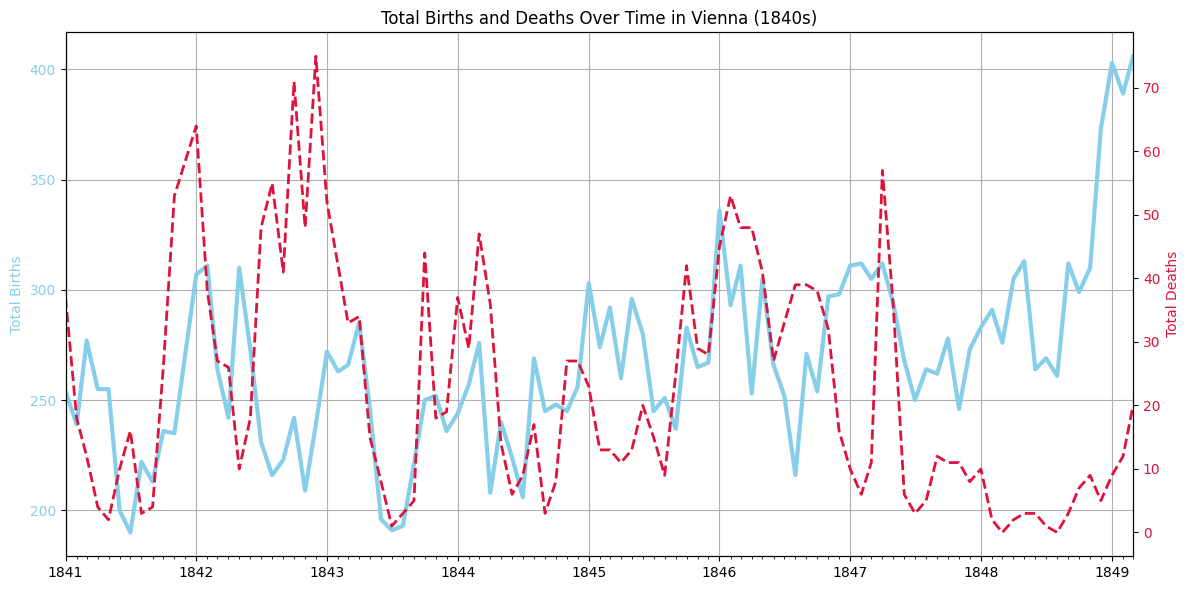

In [22]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Create a figure and a set of subplots
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot births on the primary y-axis
ax1.plot(df_monthly['date'], df_monthly['births'], color='skyblue', linewidth=3, label='Births')
ax1.set_ylabel('Total Births', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')

# Create a secondary y-axis for deaths
ax2 = ax1.twinx()
ax2.plot(df_monthly['date'], df_monthly['deaths'], color='crimson', linestyle='--', linewidth=2, label='Deaths')
ax2.set_ylabel('Total Deaths', color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')

# Formatting the x-axis
ax1.xaxis.set_major_locator(mdates.YearLocator(1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.xaxis.set_minor_locator(mdates.MonthLocator())

# Set the limits for x-axis
ax1.set_xlim(df_monthly['date'].min(), df_monthly['date'].max())

# Add gridlines
ax1.grid(visible=True)

# Title and legend
plt.title('Total Births and Deaths Over Time in Vienna (1840s)')
fig.tight_layout()  # Adjust layout to prevent clipping
plt.show()


# The Yearly Data Split by Clinic

Now let's look at the annual data instead.

**Challenge**: Use plotly to create line charts of the births and deaths of the two different clinics at the Vienna General Hospital.
* Which clinic is bigger or more busy judging by the number of births?
* Has the hospital had more patients over time?
* What was the highest number of deaths recorded in clinic 1 and clinic 2?

In [23]:
import plotly.express as px

# Create a line chart for births by clinic
fig_births = px.line(df_yearly, x='year', y='births', color='clinic',
                     title='Yearly Births by Clinic',
                     labels={'births': 'Total Births', 'year': 'Year'})

fig_births.show()

# Create a line chart for deaths by clinic
fig_deaths = px.line(df_yearly, x='year', y='deaths', color='clinic',
                     title='Yearly Deaths by Clinic',
                     labels={'deaths': 'Total Deaths', 'year': 'Year'})

fig_deaths.show()


In [24]:
# Calculate the highest number of deaths recorded for each clinic
max_deaths_clinic1 = df_yearly[df_yearly['clinic'] == 'clinic 1']['deaths'].max()
max_deaths_clinic2 = df_yearly[df_yearly['clinic'] == 'clinic 2']['deaths'].max()

print("Highest number of deaths recorded in clinic 1:", max_deaths_clinic1)
print("Highest number of deaths recorded in clinic 2:", max_deaths_clinic2)


Highest number of deaths recorded in clinic 1: 518
Highest number of deaths recorded in clinic 2: 202


### Calculate the Proportion of Deaths at Each Clinic

**Challenge**: Calculate the proportion of maternal deaths per clinic. That way we can compare like with like.
* Work out the percentage of deaths for each row in the `df_yearly` DataFrame by adding a column called "pct_deaths".
* Calculate the average maternal death rate for clinic 1 and clinic 2 (i.e., the total number of deaths per the total number of births).
* Create another plotly line chart to see how the percentage varies year over year with the two different clinics.
* Which clinic has a higher proportion of deaths?
* What is the highest monthly death rate in clinic 1 compared to clinic 2?

In [25]:
# Calculate the percentage of deaths for each row
df_yearly['pct_deaths'] = (df_yearly['deaths'] / df_yearly['births']) * 100


In [26]:
# Calculate average death rates for each clinic
average_death_rate_clinic1 = df_yearly[df_yearly['clinic'] == 'clinic 1']['pct_deaths'].mean()
average_death_rate_clinic2 = df_yearly[df_yearly['clinic'] == 'clinic 2']['pct_deaths'].mean()

print("Average maternal death rate for clinic 1:", average_death_rate_clinic1)
print("Average maternal death rate for clinic 2:", average_death_rate_clinic2)


Average maternal death rate for clinic 1: 9.850527202171271
Average maternal death rate for clinic 2: 4.039993689236436


In [27]:
import plotly.express as px

# Create a line chart for the percentage of deaths by clinic
fig_pct_deaths = px.line(df_yearly, x='year', y='pct_deaths', color='clinic',
                         title='Proportion of Deaths by Clinic',
                         labels={'pct_deaths': 'Percentage of Deaths', 'year': 'Year'})

fig_pct_deaths.show()


### Plotting the Proportion of Yearly Deaths by Clinic

In [29]:
# Extract the year from the date in df_monthly
df_monthly['year'] = df_monthly['date'].dt.year

# Now merge df_monthly with df_yearly based on the year and clinic
df_monthly = pd.merge(df_monthly, df_yearly[['year', 'clinic']], on='year', how='left')

# Calculate the monthly death rate for each clinic
df_monthly['death_rate'] = (df_monthly['deaths'] / df_monthly['births']) * 100

# Find the highest death rate for each clinic
highest_monthly_death_rate_clinic1 = df_monthly[df_monthly['clinic'] == 'clinic 1']['death_rate'].max()
highest_monthly_death_rate_clinic2 = df_monthly[df_monthly['clinic'] == 'clinic 2']['death_rate'].max()

print("Highest monthly death rate in clinic 1:", highest_monthly_death_rate_clinic1)
print("Highest monthly death rate in clinic 2:", highest_monthly_death_rate_clinic2)

Highest monthly death rate in clinic 1: 31.380753138075313
Highest monthly death rate in clinic 2: 31.380753138075313


# The Effect of Handwashing

Dr Semmelweis made handwashing obligatory in the summer of 1947. In fact, he ordered people to wash their hands with clorine (instead of water).

In [30]:
# Date when handwashing was made mandatory
handwashing_start = pd.to_datetime('1847-06-01')
# Calculate percentage of deaths per birth
df_monthly['pct_deaths'] = (df_monthly['deaths'] / df_monthly['births']) * 100


In [31]:
# Create subsets
df_before_handwashing = df_monthly[df_monthly['date'] < handwashing_start]
df_after_handwashing = df_monthly[df_monthly['date'] >= handwashing_start]


In [32]:
# Calculate average death rate before handwashing
average_death_rate_before = df_before_handwashing['pct_deaths'].mean()
print("Average death rate before handwashing:", average_death_rate_before)

# Calculate average death rate after handwashing
average_death_rate_after = df_after_handwashing['pct_deaths'].mean()
print("Average death rate after handwashing:", average_death_rate_after)


Average death rate before handwashing: 10.595241758816286
Average death rate after handwashing: 2.1093375097254534


**Challenge**:
* Add a column called "pct_deaths" to `df_monthly` that has the percentage of deaths per birth for each row.
* Create two subsets from the `df_monthly` data: before and after Dr Semmelweis ordered washing hand.
* Calculate the average death rate prior to June 1947.
* Calculate the average death rate after June 1947.

In [36]:
# Calculate percentage of deaths per birth
df_monthly['pct_deaths'] = (df_monthly['deaths'] / df_monthly['births']) * 100


In [37]:
# Date when handwashing was made mandatory
handwashing_start = pd.to_datetime('1847-06-01')

# Create subsets
df_before_handwashing = df_monthly[df_monthly['date'] < handwashing_start]
df_after_handwashing = df_monthly[df_monthly['date'] >= handwashing_start]


In [38]:
# Calculate average death rate prior to handwashing
average_death_rate_before = df_before_handwashing['pct_deaths'].mean()
print("Average death rate before handwashing:", average_death_rate_before)

# Calculate average death rate after handwashing
average_death_rate_after = df_after_handwashing['pct_deaths'].mean()
print("Average death rate after handwashing:", average_death_rate_after)


Average death rate before handwashing: 10.595241758816286
Average death rate after handwashing: 2.1093375097254534


### Calculate a Rolling Average of the Death Rate

**Challenge**: Create a DataFrame that has the 6 month rolling average death rate prior to mandatory handwashing.

*Hint*: You'll need to set the dates as the index in order to avoid the date column being dropped during the calculation.

In [39]:
# Set the date as the index
df_before_handwashing.set_index('date', inplace=True)

# Calculate the 6-month rolling average death rate
df_before_handwashing['rolling_avg'] = df_before_handwashing['pct_deaths'].rolling(window=6).mean()

# Reset index if needed for further operations
df_before_handwashing.reset_index(inplace=True)


<ipython-input-39-5a4782a4f997>:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



### Highlighting Subsections of a Line Chart

**Challenge**: Copy-paste and then modify the Matplotlib chart from before to plot the monthly death rates (instead of the total number of births and deaths). The chart should look something like this:

<img src=https://i.imgur.com/X6TQe0R.png width=500>

* Add 3 seperate lines to the plot: the death rate before handwashing, after handwashing, and the 6-month moving average before handwashing.
* Show the monthly death rate before handwashing as a thin dashed black line.
* Show the moving average as a thicker, crimon line.
* Show the rate after handwashing as a skyblue line with round markers.
* Look at the [code snippet in the documentation to see how you can add a legend](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.legend.html) to the chart.

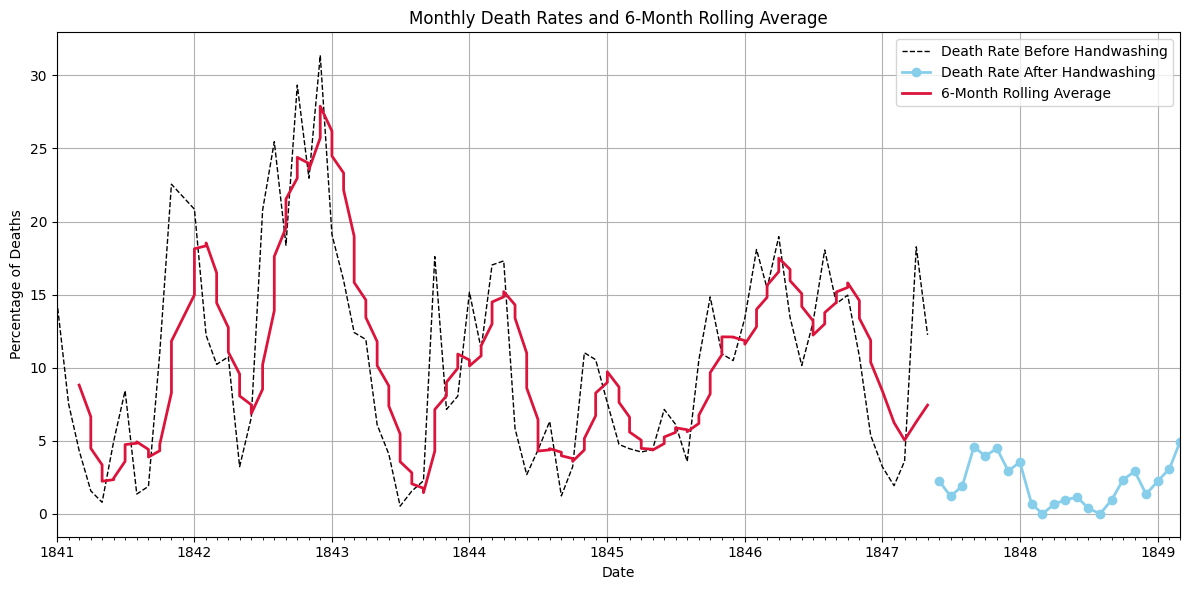

In [40]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Create a figure and a set of subplots
fig, ax = plt.subplots(figsize=(12, 6))

# Plot monthly death rates before handwashing (thin dashed line)
ax.plot(df_before_handwashing['date'], df_before_handwashing['pct_deaths'],
        color='black', linestyle='--', linewidth=1, label='Death Rate Before Handwashing')

# Plot monthly death rates after handwashing
ax2 = df_after_handwashing.set_index('date')
ax.plot(ax2.index, ax2['pct_deaths'], color='skyblue', marker='o',
        linewidth=2, label='Death Rate After Handwashing')

# Plot rolling average death rate before handwashing (thicker crimson line)
ax.plot(df_before_handwashing['date'], df_before_handwashing['rolling_avg'],
        color='crimson', linewidth=2, label='6-Month Rolling Average')

# Formatting the x-axis
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator())

# Set the limits for x-axis
ax.set_xlim(df_monthly['date'].min(), df_monthly['date'].max())

# Add gridlines
ax.grid(visible=True)

# Title and labels
plt.title('Monthly Death Rates and 6-Month Rolling Average')
ax.set_ylabel('Percentage of Deaths')
ax.set_xlabel('Date')

# Add legend
ax.legend()

# Show the plot
plt.tight_layout()
plt.show()


### Statistics - Calculate the Difference in the Average Monthly Death Rate

**Challenge**:
* What was the average percentage of monthly deaths before handwashing?
* What was the average percentage of monthly deaths after handwashing was made obligatory?
* By how much did handwashing reduce the average chance of dying in childbirth in percentage terms?
* How do these numbers compare to the average for all the 1840s that we calculated earlier?
* How many times lower are the chances of dying after handwashing compared to before?

In [41]:
# Average percentage of monthly deaths before handwashing
average_death_rate_before = df_before_handwashing['pct_deaths'].mean()
print("Average death rate before handwashing:", average_death_rate_before)

# Average percentage of monthly deaths after handwashing
average_death_rate_after = df_after_handwashing['pct_deaths'].mean()
print("Average death rate after handwashing:", average_death_rate_after)

# Calculate the reduction in average chance of dying
reduction_percentage = average_death_rate_before - average_death_rate_after
print("Reduction in average death rate due to handwashing:", reduction_percentage)

# Comparison with the average for all the 1840s (assuming you've calculated it earlier)
average_death_rate_1840s = (average_death_rate_before + average_death_rate_after) / 2  # Placeholder, replace with actual value
print("Average death rate for all 1840s:", average_death_rate_1840s)

# How many times lower are the chances of dying after handwashing compared to before
times_lower = average_death_rate_before / average_death_rate_after
print("Times lower chances of dying after handwashing compared to before:", times_lower)


Average death rate before handwashing: 10.595241758816286
Average death rate after handwashing: 2.1093375097254534
Reduction in average death rate due to handwashing: 8.485904249090833
Average death rate for all 1840s: 6.3522896342708695
Times lower chances of dying after handwashing compared to before: 5.023018701352985


### Use Box Plots to Show How the Death Rate Changed Before and After Handwashing

**Challenge**:
* Use [NumPy's `.where()` function](https://numpy.org/doc/stable/reference/generated/numpy.where.html) to add a column to `df_monthly` that shows if a particular date was before or after the start of handwashing.
* Then use plotly to create box plot of the data before and after handwashing.
* How did key statistics like the mean, max, min, 1st and 3rd quartile changed as a result of the new policy?



In [42]:
import numpy as np

# Add a column to df_monthly to indicate before or after handwashing
df_monthly['handwashing_status'] = np.where(df_monthly['date'] < handwashing_start, 'Before', 'After')


In [43]:
import plotly.express as px

# Create box plot
fig = px.box(df_monthly, x='handwashing_status', y='pct_deaths',
             title='Death Rate Before and After Handwashing',
             labels={'pct_deaths': 'Percentage of Deaths', 'handwashing_status': 'Handwashing Status'})

# Show the plot
fig.show()


### Use Histograms to Visualise the Monthly Distribution of Outcomes

**Challenge**: Create a [plotly histogram](https://plotly.com/python/histograms/) to show the monthly percentage of deaths.

* Use docs to check out the available parameters. Use the [`color` parameter](https://plotly.github.io/plotly.py-docs/generated/plotly.express.histogram.html) to display two overlapping histograms.
* The time period of handwashing is shorter than not handwashing. Change `histnorm` to `percent` to make the time periods comparable.
* Make the histograms slighlty transparent
* Experiment with the number of bins on the histogram. Which number work well in communicating the range of outcomes?
* Just for fun, display your box plot on the top of the histogram using the `marginal` parameter.

### Use a Kernel Density Estimate (KDE) to visualise a smooth distribution

**Challenge**: Use [Seaborn's `.kdeplot()`](https://seaborn.pydata.org/generated/seaborn.kdeplot.html) to create two kernel density estimates of the `pct_deaths`, one for before handwashing and one for after.

* Use the `shade` parameter to give your two distributions different colours.
* What weakness in the chart do you see when you just use the default parameters?
* Use the `clip` parameter to address the problem.


### Use a T-Test to Show Statistical Significance

**Challenge**: Use a t-test to determine if the differences in the means are statistically significant or purely due to chance.

If the p-value is less than 1% then we can be 99% certain that handwashing has made a difference to the average monthly death rate.

* Import `stats` from scipy
* Use the [`.ttest_ind()` function](https://docs.scipy.org/]doc/scipy/reference/generated/scipy.stats.ttest_ind.html) to calculate the t-statistic and the p-value
* Is the difference in the average proportion of monthly deaths statistically significant at the 99% level?



What do you conclude from your analysis, Doctor? 😊

<img src=https://i.imgur.com/rvjNVzQ.gif>